In [7]:
import pandas as pd

df = pd.read_csv('onlineretail.csv') 

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  str    
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 33.1 MB
None


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('onlineretail.csv')

df = df.dropna(subset=['CustomerID']) 

df['CustomerID'] = df['CustomerID'].astype(int)

df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)

df['Total_Spent'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed', errors='coerce')
df = df.dropna(subset=['InvoiceDate'])

print("Limpeza concluída com sucesso! Total de linhas:", len(df))

Limpeza concluída com sucesso! Total de linhas: 406829


In [9]:
base1 = df.groupby('CustomerID').agg(
    Frequencia_Retorno=('InvoiceNo', 'nunique'), 
    Gasto_Total=('Total_Spent', 'sum'),          
    Primeira_Visita=('InvoiceDate', 'min'),
    Ultima_Visita=('InvoiceDate', 'max')
).reset_index()

data_atual_simulada = df['InvoiceDate'].max()
base1['Dias_Desde_Ultima_Visita'] = (data_atual_simulada - base1['Ultima_Visita']).dt.days
base1_clusterizacao = base1[['CustomerID', 'Frequencia_Retorno', 'Gasto_Total', 'Dias_Desde_Ultima_Visita']]

print("Base 1 criada! Clientes únicos para clusterizar:", len(base1_clusterizacao))

Base 1 criada! Clientes únicos para clusterizar: 4372


In [10]:
df_sorted = df.sort_values(by=['CustomerID', 'InvoiceDate'])

base2 = df_sorted.drop_duplicates(subset=['CustomerID'], keep='first').copy()

base2['Mes_da_Compra'] = base2['InvoiceDate'].dt.month
base2['Dia_da_Semana'] = base2['InvoiceDate'].dt.dayofweek
base2['Gasto_Inicial'] = base2['Total_Spent']
base2['Qtd_Itens_Iniciais'] = base2['Quantity']

base2_classificacao = base2[['CustomerID', 'Mes_da_Compra', 'Dia_da_Semana', 'Gasto_Inicial', 'Qtd_Itens_Iniciais', 'Country']]

print("Base 2 criada! Pronta para prever o futuro sem vazar dados.")

Base 2 criada! Pronta para prever o futuro sem vazar dados.


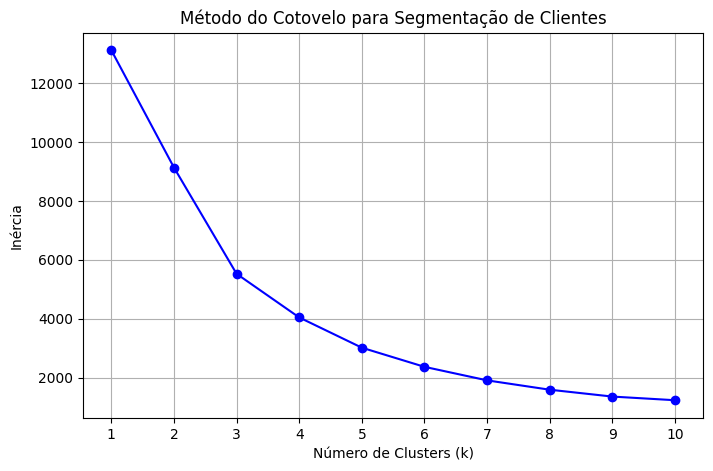

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = base1_clusterizacao[['Frequencia_Retorno', 'Gasto_Total', 'Dias_Desde_Ultima_Visita']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# 4. Plotando o gráfico do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o', linestyle='-', color='b')
plt.title('Método do Cotovelo para Segmentação de Clientes')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [12]:
import warnings
warnings.filterwarnings('ignore') 

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

base1_clusterizacao = base1_clusterizacao.copy()
base1_clusterizacao['Cluster'] = kmeans_final.fit_predict(X_scaled)

analise_perfis = base1_clusterizacao.groupby('Cluster').agg(
    Qtd_Clientes=('CustomerID', 'count'),
    Frequencia_Media=('Frequencia_Retorno', 'mean'),
    Gasto_Medio=('Gasto_Total', 'mean'),
    Dias_Ausente_Medio=('Dias_Desde_Ultima_Visita', 'mean')
).round(2)

print(analise_perfis)

         Qtd_Clientes  Frequencia_Media  Gasto_Medio  Dias_Ausente_Medio
Cluster                                                                 
0                3169              4.80      1478.52               40.61
1                1087              1.81       453.49              246.95
2                   6             89.00    182181.98                6.67
3                 110             40.67     18441.96                8.18


=== ACURÁCIA GERAL ===
66.39%

=== RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1) ===
              precision    recall  f1-score   support

0: Econômico       0.76      0.81      0.78       951
 1: Abandono       0.37      0.31      0.34       326
 2: Frotista       0.00      0.00      0.00         2
     3: Fiel       0.04      0.03      0.03        33

    accuracy                           0.66      1312
   macro avg       0.29      0.29      0.29      1312
weighted avg       0.64      0.66      0.65      1312



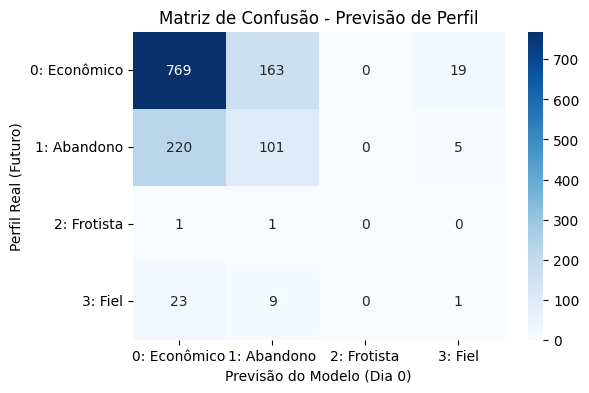


=== TOP 5 VARIÁVEIS MAIS IMPORTANTES NO DIA DA COMPRA ===
Gasto_Inicial             0.322991
Mes_da_Compra             0.262317
Qtd_Itens_Iniciais        0.185259
Dia_da_Semana             0.112284
Country_United Kingdom    0.040713
dtype: float64


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

rotulos = base1_clusterizacao[['CustomerID', 'Cluster']]
df_modelo = pd.merge(base2_classificacao, rotulos, on='CustomerID', how='inner')

df_modelo = pd.get_dummies(df_modelo, columns=['Country'], drop_first=True)

X = df_modelo.drop(['CustomerID', 'Cluster'], axis=1)
y = df_modelo['Cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_test)

print("=== ACURÁCIA GERAL ===")
print(f"{accuracy_score(y_test, y_pred):.2%}\n")

print("=== RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1) ===")
nomes_classes = ['0: Econômico', '1: Abandono', '2: Frotista', '3: Fiel']
classes_presentes = [nomes_classes[i] for i in sorted(y_test.unique())]
print(classification_report(y_test, y_pred, target_names=classes_presentes))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_presentes, yticklabels=classes_presentes)
plt.title('Matriz de Confusão - Previsão de Perfil')
plt.ylabel('Perfil Real (Futuro)')
plt.xlabel('Previsão do Modelo (Dia 0)')
plt.show()

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
print("\n=== TOP 5 VARIÁVEIS MAIS IMPORTANTES NO DIA DA COMPRA ===")
print(importancias)